In [1]:
!pip install transformers torch torchvision scikit-learn pillow requests -q

In [2]:
import torch
import numpy as np
import requests
from PIL import Image

from torchvision.datasets import OxfordIIITPet
from transformers import AutoImageProcessor, AutoModel, AutoModelForImageClassification
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [4]:
# Load Oxford-IIIT Pet dataset
dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True
)

# DINOv2 model for CLS token extraction
model_name = "facebook/dinov2-small"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

# Oxford-IIIT Pet:
# labels 0-11 = cats
# labels 12-36 = dogs

cat_indices = []
dog_indices = []

for i in range(len(dataset)):
    image, label = dataset[i]

    if label <= 11 and len(cat_indices) < 10:
        cat_indices.append(i)
    elif label >= 12 and len(dog_indices) < 10:
        dog_indices.append(i)

    if len(cat_indices) == 10 and len(dog_indices) == 10:
        break

selected_indices = cat_indices + dog_indices

# Ground-truth labels:
# 0 = cat, 1 = dog
true_labels = [0] * 10 + [1] * 10

features = []

for count, idx in enumerate(selected_indices):
    print(f"Processing image {count+1}/20")

    image, original_label = dataset[idx]
    image = image.convert("RGB")

    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # Extract CLS token: shape = [1, 384]
    cls_token = outputs.last_hidden_state[:, 0, :]

    features.append(cls_token.squeeze().cpu().numpy())

features = np.array(features)

print("Feature shape:", features.shape)

100%|██████████| 792M/792M [00:38<00:00, 20.6MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 8.50MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Processing image 1/20
Processing image 2/20
Processing image 3/20
Processing image 4/20
Processing image 5/20
Processing image 6/20
Processing image 7/20
Processing image 8/20
Processing image 9/20
Processing image 10/20
Processing image 11/20
Processing image 12/20
Processing image 13/20
Processing image 14/20
Processing image 15/20
Processing image 16/20
Processing image 17/20
Processing image 18/20
Processing image 19/20
Processing image 20/20
Feature shape: (20, 384)


In [5]:
# K-Means clustering with n = 2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

pred_clusters = kmeans.fit_predict(features)

print("Predicted clusters:")
print(pred_clusters)

print("Ground-truth labels:")
print(true_labels)

# Cluster labels may be reversed, so test both cases
acc1 = accuracy_score(true_labels, pred_clusters)
acc2 = accuracy_score(true_labels, 1 - pred_clusters)

if acc2 > acc1:
    final_predictions = 1 - pred_clusters
else:
    final_predictions = pred_clusters

best_acc = max(acc1, acc2)

print(f"Best Clustering Accuracy: {best_acc * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, final_predictions))

print("\nClassification Report:")
print(classification_report(true_labels, final_predictions, target_names=["Cat", "Dog"]))

Predicted clusters:
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
Ground-truth labels:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Best Clustering Accuracy: 100.00%

Confusion Matrix:
[[10  0]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

         Cat       1.00      1.00      1.00        10
         Dog       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



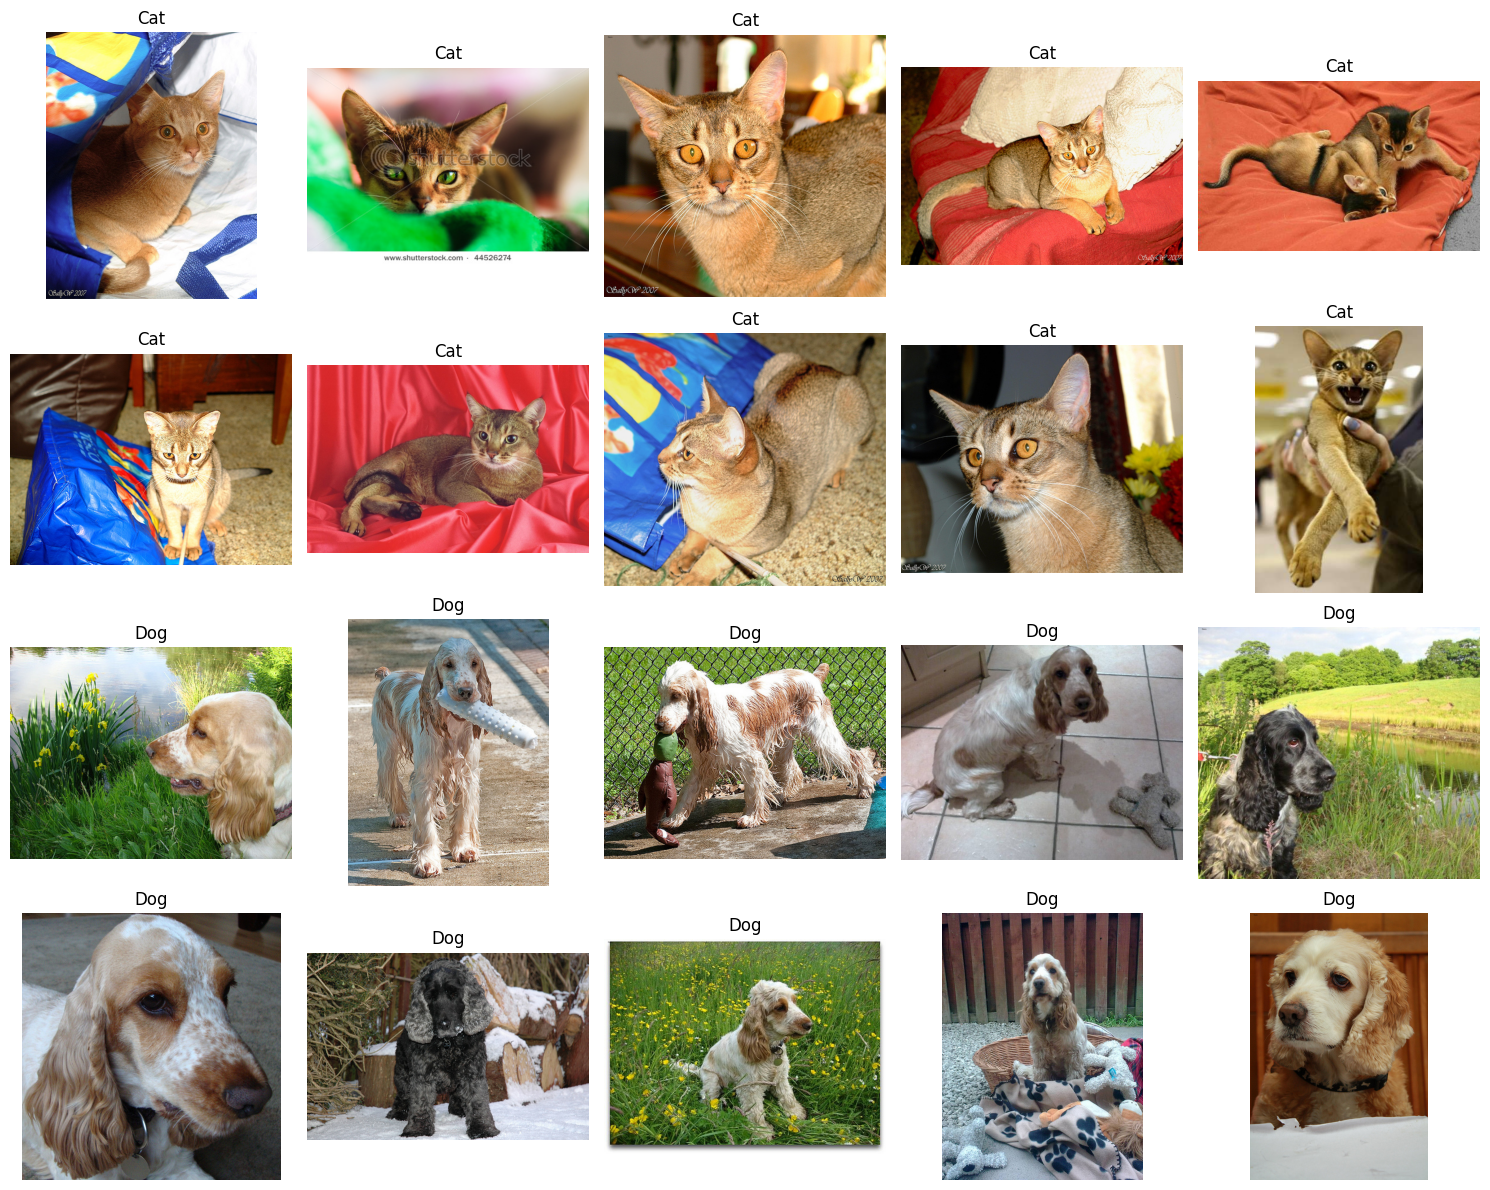

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for i, idx in enumerate(selected_indices):
    image, label = dataset[idx]

    ax = axes[i // 5, i % 5]

    ax.imshow(image)

    if label <= 11:
        title = "Cat"
    else:
        title = "Dog"

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
model_id = "facebook/dinov2-small-imagenet1k-1-layer"

classifier_processor = AutoImageProcessor.from_pretrained(model_id)
classifier_model = AutoModelForImageClassification.from_pretrained(model_id).to(device)
classifier_model.eval()

# Example ImageNet class image: Golden Retriever
image_url = "https://images.unsplash.com/photo-1552053831-71594a27632d?w=224"

image = Image.open(requests.get(image_url, stream=True, timeout=10).raw).convert("RGB")

inputs = classifier_processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = classifier_model(**inputs)

logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()
predicted_label = classifier_model.config.id2label[predicted_class_idx]

print("Predicted class index:", predicted_class_idx)
print("Predicted label:", predicted_label)

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Predicted class index: 207
Predicted label: golden retriever
